In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter
import warnings
warnings.filterwarnings('ignore')

In [3]:
# 1. Tải dữ liệu
orders = pd.read_csv('dataset/orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv('dataset/order_items.csv', dtype={'promo_id_2': str})
customers = pd.read_csv('dataset/customers.csv', parse_dates=['signup_date'])

In [4]:
# 2. Chuẩn bị dữ liệu cho mô hình RFM
# Tính doanh thu từng mặt hàng (Doanh thu = quantity * unit_price)
order_items['revenue'] = order_items['quantity'] * order_items['unit_price']

# Tính tổng doanh thu theo từng đơn hàng
order_revenue = order_items.groupby('order_id')['revenue'].sum().reset_index()

# Gộp dữ liệu đơn hàng và doanh thu để lấy customer_id và order_date
orders_revenue = pd.merge(orders, order_revenue, on='order_id', how='inner')

# Lấy mốc thời gian tham chiếu (Thường là 1 ngày sau ngày mua hàng cuối cùng trong tệp dữ liệu)
reference_date = orders_revenue['order_date'].max() + pd.Timedelta(days=1)

# Tính các chỉ số R (Recency), F (Frequency), M (Monetary) cho từng khách hàng
rfm = orders_revenue.groupby('customer_id').agg(
    Recency=('order_date', lambda x: (reference_date - x.max()).days),
    Frequency=('order_id', 'nunique'),
    Monetary=('revenue', 'sum')
).reset_index()

In [5]:
# 3. Phân khúc khách hàng theo hệ điểm (Dùng qcut chia làm 3 nhóm)
# Recency: Số ngày càng nhỏ càng tốt (Điểm 3 là tốt nhất, 1 là kém nhất)
rfm['R_Score'] = pd.qcut(rfm['Recency'], 3, labels=[3, 2, 1])
# Frequency: Số lượng đơn hàng càng lớn càng tốt
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 3, labels=[1, 2, 3]) 
# Monetary: Tổng chi tiêu càng lớn càng tốt
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 3, labels=[1, 2, 3])

# Gắn nhãn phân khúc (Segmentation)
def segment_customer(row):
    if row['R_Score'] == 3 and row['F_Score'] == 3 and row['M_Score'] == 3:
        return 'Champions (Khách VIP)'
    elif row['R_Score'] == 1 and row['M_Score'] == 3:
        return 'At Risk (Sắp rời bỏ - Cần cứu)'
    elif row['R_Score'] == 3 and row['F_Score'] == 1:
        return 'New Customers (Khách mới)'
    elif row['R_Score'] == 1 and row['F_Score'] == 1:
        return 'Lost (Đã mất)'
    else:
        return 'Regular (Thường xuyên)'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

# Gộp bảng RFM với thông tin khách hàng (Nhân khẩu học)
rfm_cust = pd.merge(rfm, customers, on='customer_id', how='left')
# Loại bỏ các dòng bị thiếu dữ liệu tuổi/giới tính để vẽ biểu đồ sạch hơn
rfm_cust = rfm_cust.dropna(subset=['age_group', 'gender'])

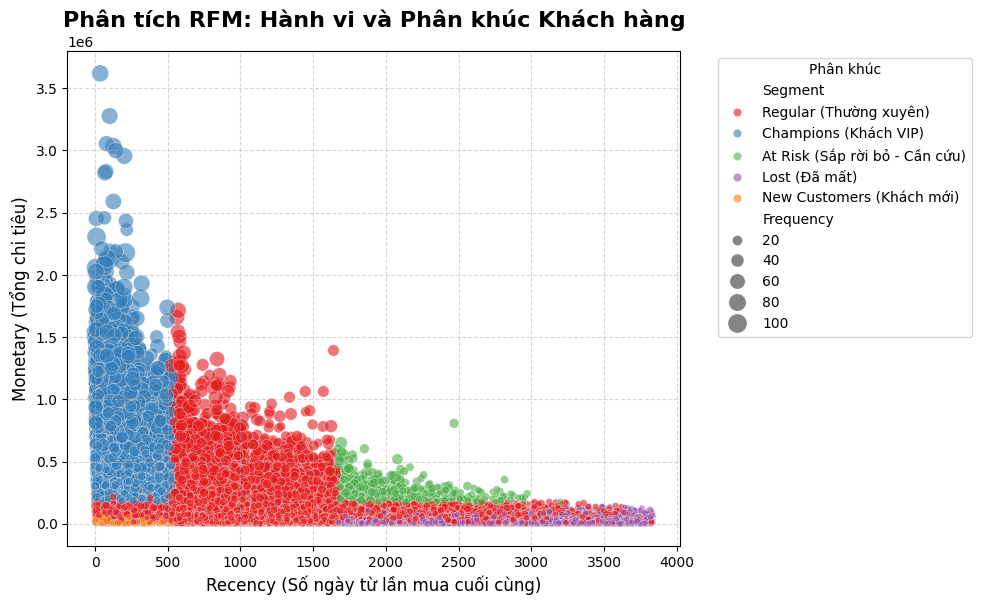

In [6]:
# ==========================================
# BIỂU ĐỒ 1: BIỂU ĐỒ PHÂN TÁN RFM (SCATTER PLOT)
# ==========================================
plt.figure(figsize=(10, 6))
# Trục X: Recency, Trục Y: Monetary, Kích thước bong bóng: Frequency, Màu sắc: Phân khúc
sns.scatterplot(
    data=rfm, 
    x='Recency', 
    y='Monetary', 
    hue='Segment', 
    size='Frequency',
    sizes=(20, 200), # Tuỳ chỉnh độ lớn của bong bóng
    alpha=0.6,
    palette='Set1'
)
plt.title('Phân tích RFM: Hành vi và Phân khúc Khách hàng', fontsize=16, fontweight='bold')
plt.xlabel('Recency (Số ngày từ lần mua cuối cùng)', fontsize=12)
plt.ylabel('Monetary (Tổng chi tiêu)', fontsize=12)

# Tùy chỉnh hiển thị
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Phân khúc")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

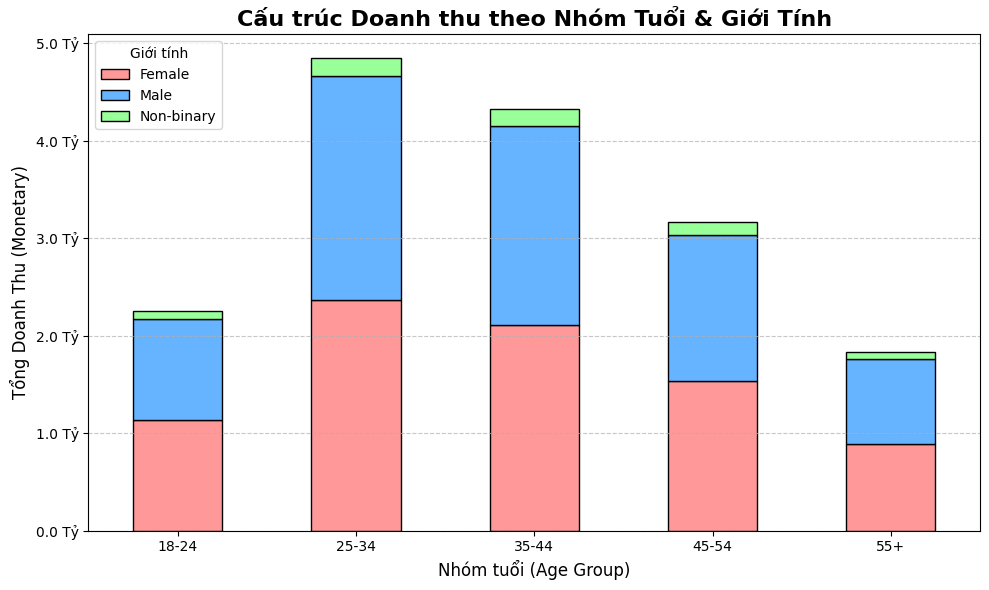

In [7]:
# ==========================================
# BIỂU ĐỒ 2: BIỂU ĐỒ CỘT CHỒNG (STACKED BAR CHART)
# Doanh thu (Monetary) theo Nhóm Tuổi và Giới tính
# ==========================================
# Nhóm dữ liệu
demo_monetary = rfm_cust.groupby(['age_group', 'gender'])['Monetary'].sum().unstack()

# Sắp xếp lại thứ tự nhóm tuổi cho chuẩn logic
age_order = ['18-24', '25-34', '35-44', '45-54', '55+']
demo_monetary = demo_monetary.reindex(age_order)

# Vẽ biểu đồ
colors = ['#ff9999', '#66b3ff', '#99ff99'] # Màu sắc tùy chọn cho giới tính
ax = demo_monetary.plot(kind='bar', stacked=True, figsize=(10, 6), color=colors, edgecolor='black')

plt.title('Cấu trúc Doanh thu theo Nhóm Tuổi & Giới Tính', fontsize=16, fontweight='bold')
plt.xlabel('Nhóm tuổi (Age Group)', fontsize=12)
plt.ylabel('Tổng Doanh Thu (Monetary)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Giới tính', loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Định dạng trục Y cho dễ nhìn (vd: 1.5B thay vì 1500000000)
def format_currency(value, tick_number):
    return f'{value/1e9:.1f} Tỷ' 

ax.yaxis.set_major_formatter(plt.FuncFormatter(format_currency))

plt.tight_layout()
plt.show()

In [8]:
# ==========================================
# 1. TẢI VÀ CHUẨN BỊ DỮ LIỆU
# ==========================================
print("Đang tải dữ liệu...")
inventory = pd.read_csv('dataset/inventory.csv', parse_dates=['snapshot_date'])
sales = pd.read_csv('dataset/sales.csv', parse_dates=['Date'])
products = pd.read_csv('dataset/products.csv')

Đang tải dữ liệu...


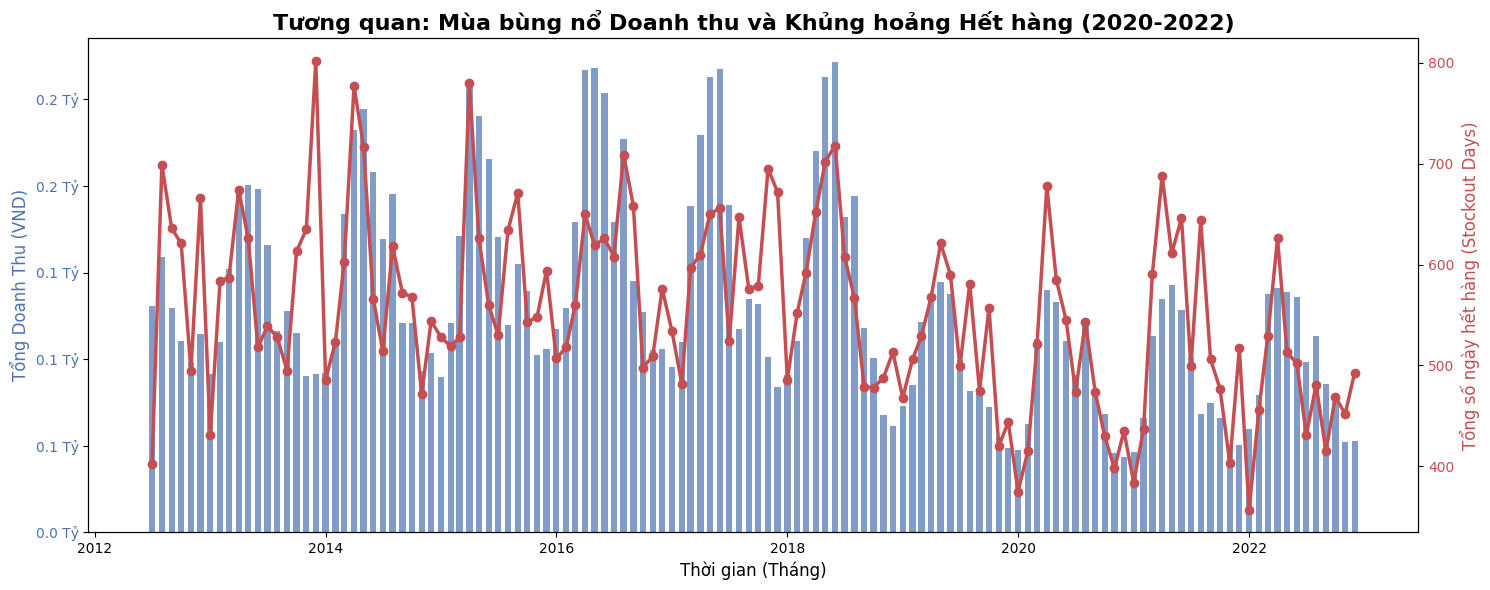

In [9]:
# ==========================================
# BIỂU ĐỒ 1: TƯƠNG QUAN DOANH THU & SỐ NGÀY HẾT HÀNG (DUAL-AXIS)
# ==========================================
# Nhóm doanh thu theo tháng-năm
sales['YearMonth'] = sales['Date'].dt.to_period('M')
monthly_revenue = sales.groupby('YearMonth')['Revenue'].sum().reset_index()

# Nhóm tổng số ngày hết hàng (stockout_days) theo tháng-năm
inventory['YearMonth'] = inventory['snapshot_date'].dt.to_period('M')
monthly_stockout = inventory.groupby('YearMonth')['stockout_days'].sum().reset_index()

# Kết hợp 2 bảng
df_trend = pd.merge(monthly_revenue, monthly_stockout, on='YearMonth', how='inner')
# Chuyển lại định dạng datetime để vẽ trục X dễ dàng hơn
df_trend['YearMonth'] = df_trend['YearMonth'].dt.to_timestamp()

# Lọc lấy giai đoạn 3 năm gần nhất (ví dụ từ 2020) để biểu đồ không bị quá chậtt chội
# df_trend_recent = df_trend[df_trend['YearMonth'] >= '2020-01-01']
df_trend_recent = df_trend.copy()

# Bắt đầu vẽ biểu đồ 2 trục
fig, ax1 = plt.subplots(figsize=(15, 6))

# Trục trái (Y1) - Biểu đồ cột cho Doanh thu
color_rev = '#4C72B0'
ax1.bar(df_trend_recent['YearMonth'], df_trend_recent['Revenue'], width=20, color=color_rev, alpha=0.7, label='Doanh thu')
ax1.set_xlabel('Thời gian (Tháng)', fontsize=12)
ax1.set_ylabel('Tổng Doanh Thu (VND)', color=color_rev, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color_rev)

# Format trục Y1 sang tỷ VND
def format_currency(value, tick_number):
    return f'{value/1e9:.1f} Tỷ'
ax1.yaxis.set_major_formatter(plt.FuncFormatter(format_currency))

# Trục phải (Y2) - Biểu đồ đường cho Số ngày hết hàng
ax2 = ax1.twinx()
color_so = '#C44E52'
ax2.plot(df_trend_recent['YearMonth'], df_trend_recent['stockout_days'], color=color_so, marker='o', linewidth=2.5, label='Số ngày hết hàng')
ax2.set_ylabel('Tổng số ngày hết hàng (Stockout Days)', color=color_so, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color_so)

plt.title('Tương quan: Mùa bùng nổ Doanh thu và Khủng hoảng Hết hàng (2020-2022)', fontsize=16, fontweight='bold')
fig.tight_layout()
plt.show()

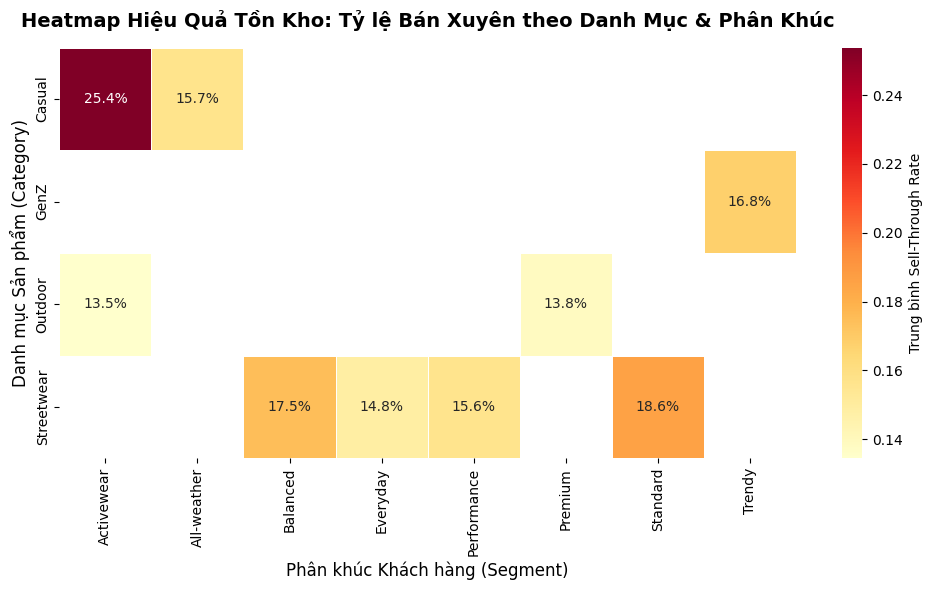

In [10]:
# ==========================================
# BIỂU ĐỒ 2: HEATMAP TỶ LỆ BÁN XUYÊN (SELL-THROUGH RATE)
# ==========================================
# Tỷ lệ bán xuyên (Sell-through rate) = Số lượng bán ra / (Số lượng bán ra + Tồn kho)
# Tỷ lệ này càng cao chứng tỏ sản phẩm lưu thông càng nhanh, vòng quay vốn càng tốt

# Lọc bỏ các dòng lỗi (nếu có null)
inv_valid = inventory.dropna(subset=['sell_through_rate', 'category', 'segment'])

# Tạo pivot table tính trung bình Sell-Through Rate theo Category và Segment
heatmap_data = inv_valid.pivot_table(
    values='sell_through_rate', 
    index='category', 
    columns='segment', 
    aggfunc='mean'
)

plt.figure(figsize=(10, 6))
# Dùng colormap "YlOrRd" (Vàng - Cam - Đỏ), màu đỏ đậm hiển thị tỷ lệ bán xuyên xuất sắc
sns.heatmap(heatmap_data, annot=True, fmt=".1%", cmap="YlOrRd", linewidths=.5, cbar_kws={'label': 'Trung bình Sell-Through Rate'})

plt.title('Heatmap Hiệu Quả Tồn Kho: Tỷ lệ Bán Xuyên theo Danh Mục & Phân Khúc', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Phân khúc Khách hàng (Segment)', fontsize=12)
plt.ylabel('Danh mục Sản phẩm (Category)', fontsize=12)

plt.tight_layout()
plt.show()

In [11]:
print("Đang tải dữ liệu...")
returns = pd.read_csv('dataset/returns.csv', parse_dates=['return_date'])
products = pd.read_csv('dataset/products.csv')
reviews = pd.read_csv('dataset/reviews.csv')
geography = pd.read_csv('dataset/geography.csv')

Đang tải dữ liệu...


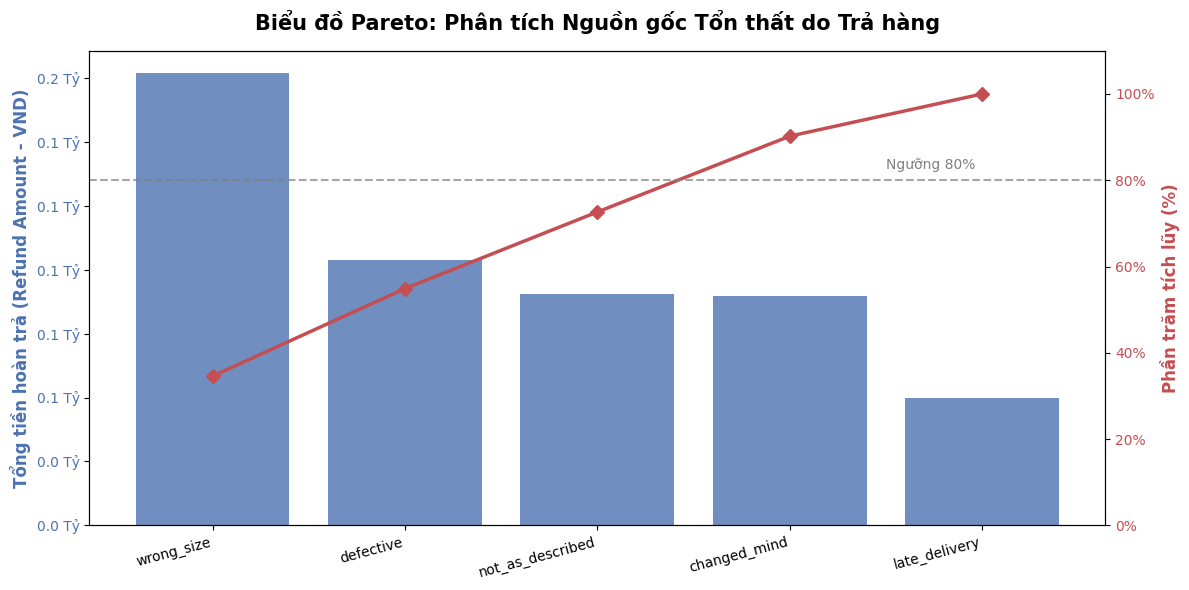

In [12]:
# Kết hợp dữ liệu Trả hàng và Sản phẩm
ret_prod = pd.merge(returns, products, on='product_id', how='inner')

# ==========================================
# BIỂU ĐỒ 1: PARETO CHART - THIỆT HẠI THEO LÝ DO TRẢ HÀNG
# ==========================================
# Tính tổng tiền hoàn (refund_amount) theo từng lý do
reason_cost = returns.groupby('return_reason')['refund_amount'].sum().reset_index()
reason_cost = reason_cost.sort_values(by='refund_amount', ascending=False)

# Tính phần trăm tích lũy (Cumulative Percentage)
reason_cost['cum_percent'] = reason_cost['refund_amount'].cumsum() / reason_cost['refund_amount'].sum() * 100

fig, ax1 = plt.subplots(figsize=(12, 6))

# Trục Y chính (Cột): Số tiền thiệt hại
color_bar = '#4C72B0'
ax1.bar(reason_cost['return_reason'], reason_cost['refund_amount'], color=color_bar, alpha=0.8)
ax1.set_ylabel('Tổng tiền hoàn trả (Refund Amount - VND)', color=color_bar, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_bar)

# Format trục Y1 sang tỷ VND
def format_currency(value, tick_number):
    return f'{value/1e9:.1f} Tỷ'
ax1.yaxis.set_major_formatter(plt.FuncFormatter(format_currency))

# Trục Y phụ (Đường): Phần trăm tích lũy
ax2 = ax1.twinx()
color_line = '#C44E52'
ax2.plot(reason_cost['return_reason'], reason_cost['cum_percent'], color=color_line, marker='D', ms=7, linewidth=2.5)
ax2.set_ylabel('Phần trăm tích lũy (%)', color=color_line, fontsize=12, fontweight='bold')
ax2.yaxis.set_major_formatter(PercentFormatter())
ax2.tick_params(axis='y', labelcolor=color_line)
ax2.set_ylim(0, 110)

# Vẽ đường cutoff 80% (Quy tắc Pareto 80/20)
ax2.axhline(80, color='grey', linestyle='dashed', alpha=0.7)
ax2.text(len(reason_cost)-1.5, 82, 'Ngưỡng 80%', color='grey', fontsize=10, va='bottom')

plt.title('Biểu đồ Pareto: Phân tích Nguồn gốc Tổn thất do Trả hàng', fontsize=15, fontweight='bold', pad=15)
ax1.set_xticklabels(reason_cost['return_reason'], rotation=15, ha='right')
fig.tight_layout()
plt.show()

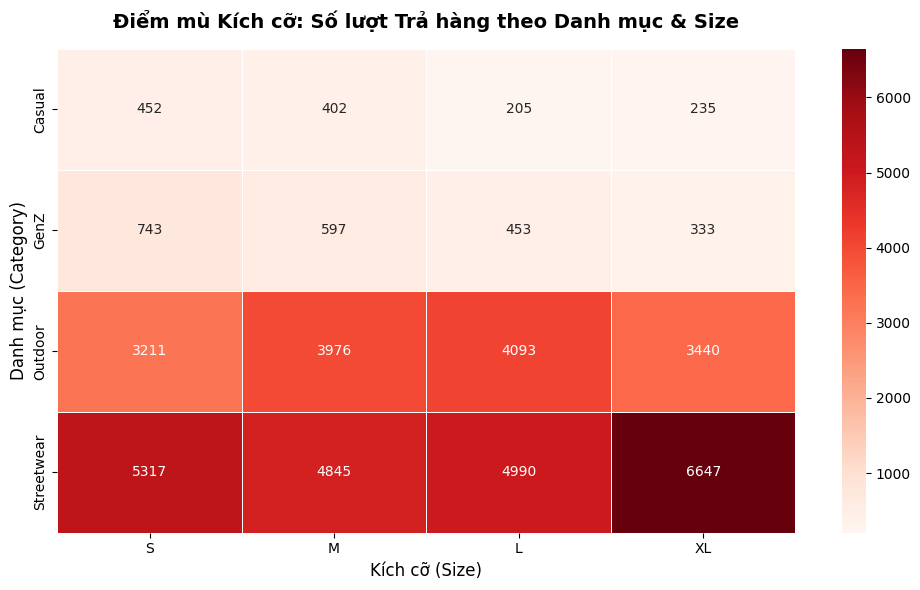

In [13]:
# ==========================================
# BIỂU ĐỒ 2: HEATMAP TRẢ HÀNG THEO CATEGORY VÀ SIZE
# ==========================================
# Đếm số lượng trả hàng theo category và size
cat_size_returns = ret_prod.groupby(['category', 'size'])['return_id'].count().reset_index()

# Chuyển đổi dạng dữ liệu sang ma trận pivot
heatmap_data = cat_size_returns.pivot_table(index='category', columns='size', values='return_id', fill_value=0)

# Sắp xếp lại thứ tự cột Size cho logic
size_order = ['S', 'M', 'L', 'XL']
heatmap_data = heatmap_data.reindex(columns=size_order)

plt.figure(figsize=(10, 6))
# Sử dụng dải màu đỏ thể hiện mức độ cảnh báo (càng đậm càng nhiều lượt trả)
heatmap_data = heatmap_data.fillna(0).astype(int)
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="Reds", linewidths=.5)

plt.title('Điểm mù Kích cỡ: Số lượt Trả hàng theo Danh mục & Size', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Kích cỡ (Size)', fontsize=12)
plt.ylabel('Danh mục (Category)', fontsize=12)

plt.tight_layout()
plt.show()

In [14]:
# 1. Tìm danh sách các sản phẩm có tỷ lệ trả hàng cao nhất
returns_count = returns.groupby('product_id').size().reset_index(name='return_qty')
# 2. Tính điểm đánh giá trung bình cho TẤT CẢ sản phẩm từ bảng reviews
avg_reviews = reviews.groupby('product_id')['rating'].mean().reset_index(name='avg_rating')

# 3. Kết hợp lại để xem tương quan
correlation_df = pd.merge(returns_count, avg_reviews, on='product_id', how='inner')

print("--- TƯƠNG QUAN GIỮA LƯỢT TRẢ HÀNG VÀ ĐIỂM RATING TỔNG THỂ ---")
# Xem 10 sản phẩm bị trả nhiều nhất có rating như thế nào
print(correlation_df.sort_values(by='return_qty', ascending=False).head(10))

# 4. Tính hệ số tương quan (Correlation)
corr_value = correlation_df['return_qty'].corr(correlation_df['avg_rating'])
print(f"\nHệ số tương quan giữa số lượng trả hàng và điểm đánh giá: {corr_value:.4f}")

--- TƯƠNG QUAN GIỮA LƯỢT TRẢ HÀNG VÀ ĐIỂM RATING TỔNG THỂ ---
      product_id  return_qty  avg_rating
429          792         619    3.907268
428          791         582    3.953042
310          604         441    3.997801
1068        2045         422    3.914588
217          487         415    3.928571
1203        2332         402    3.948602
637         1182         401    4.023789
474          927         397    3.955595
186          438         375    3.894599
447          826         360    3.823869

Hệ số tương quan giữa số lượng trả hàng và điểm đánh giá: 0.0202


In [15]:
# Giả sử bạn có bảng order_items để tính tổng số lượng bán ra
sales_qty = order_items.groupby('product_id')['quantity'].sum().reset_index(name='total_sold')

# Kết hợp với bảng correlation_df cũ
final_analysis = pd.merge(correlation_df, sales_qty, on='product_id')

# Tính Return Rate
final_analysis['return_rate'] = final_analysis['return_qty'] / final_analysis['total_sold']

# Tính tương quan mới
new_corr = final_analysis['return_rate'].corr(final_analysis['avg_rating'])
print(f"Hệ số tương quan giữa TỶ LỆ trả hàng (%) và điểm đánh giá: {new_corr:.4f}")

Hệ số tương quan giữa TỶ LỆ trả hàng (%) và điểm đánh giá: -0.1204


Đang tải dữ liệu...
Đang xử lý dữ liệu Cohort...


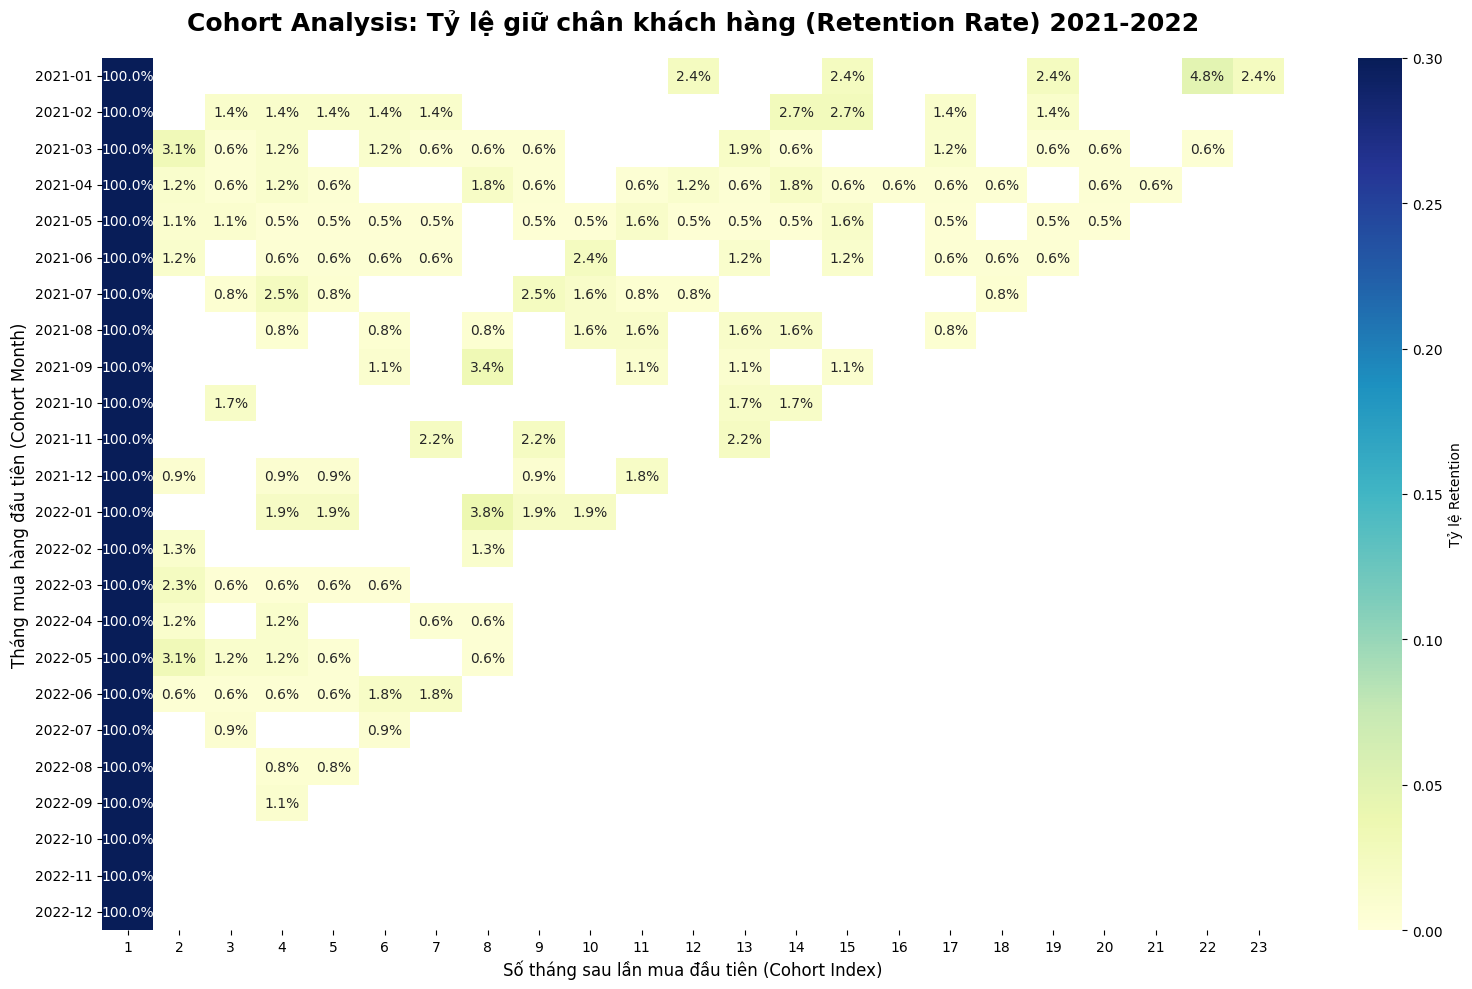

Đang xử lý dữ liệu Lợi nhuận...


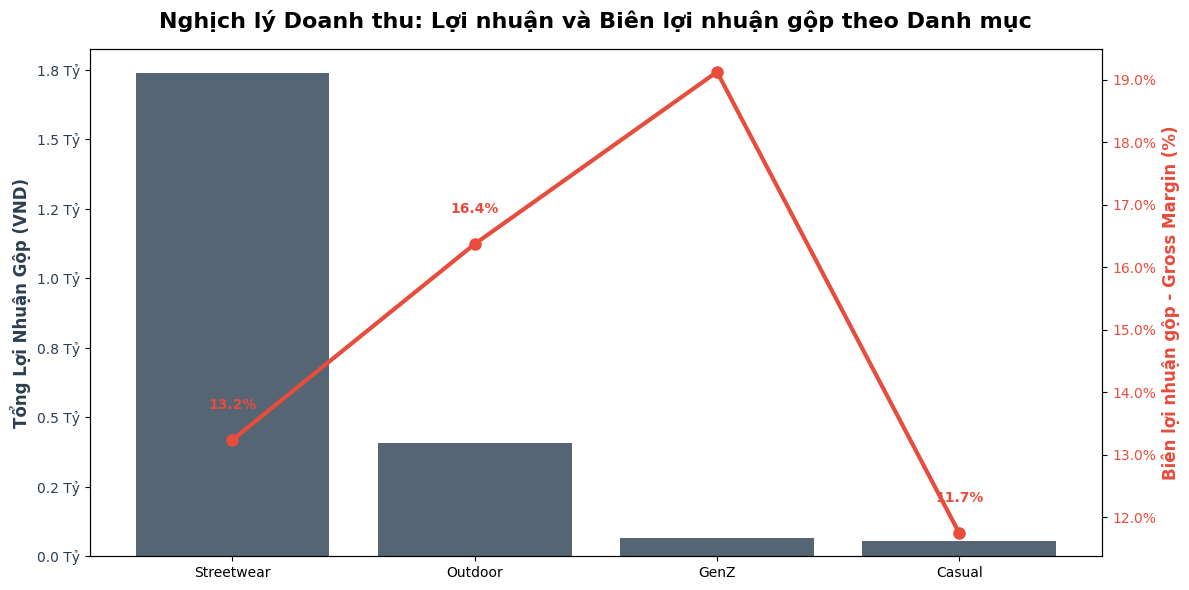

In [16]:


print("Đang tải dữ liệu...")
orders = pd.read_csv('dataset/orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv('dataset/order_items.csv', dtype={'promo_id_2': str})
products = pd.read_csv('dataset/products.csv')

# ==========================================
# INSIGHT 1: COHORT ANALYSIS (TỶ LỆ GIỮ CHÂN KHÁCH HÀNG)
# ==========================================
print("Đang xử lý dữ liệu Cohort...")
# 1. Tạo cột Tháng-Năm mua hàng (OrderMonth)
orders['OrderMonth'] = orders['order_date'].dt.to_period('M')

# 2. Tìm tháng mua hàng đầu tiên của mỗi khách hàng (CohortMonth)
orders['CohortMonth'] = orders.groupby('customer_id')['OrderMonth'].transform('min')

# 3. Hàm tính toán khoảng cách số tháng (Cohort Index)
def get_date_int(df, column):
    year = df[column].dt.year
    month = df[column].dt.month
    return year, month

order_year, order_month = get_date_int(orders, 'OrderMonth')
cohort_year, cohort_month = get_date_int(orders, 'CohortMonth')

years_diff = order_year - cohort_year
months_diff = order_month - cohort_month

# Số tháng tính từ lần mua đầu tiên (Tháng 1 là tháng mua lần đầu)
orders['CohortIndex'] = years_diff * 12 + months_diff + 1

# Lọc lấy dữ liệu của 2 năm gần nhất để biểu đồ không bị quá dài (ví dụ: 2021-2022)
recent_orders = orders[orders['CohortMonth'] >= '2021-01']

# 4. Gom nhóm và đếm số lượng khách hàng duy nhất theo Cohort
cohort_data = recent_orders.groupby(['CohortMonth', 'CohortIndex'])['customer_id'].nunique().reset_index()

# 5. Tạo ma trận Pivot
cohort_pivot = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='customer_id')

# 6. Tính tỷ lệ phần trăm giữ chân (Chia cho tháng thứ 1)
cohort_sizes = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_sizes, axis=0)

# Vẽ biểu đồ Heatmap Cohort
plt.figure(figsize=(16, 10))
plt.title('Cohort Analysis: Tỷ lệ giữ chân khách hàng (Retention Rate) 2021-2022', fontsize=18, fontweight='bold', pad=20)

sns.heatmap(retention_matrix, 
            annot=True, 
            fmt='.1%', 
            cmap='YlGnBu', 
            vmin=0.0,
            vmax=0.3, # Cap màu ở mức 30% để thấy rõ sự khác biệt
            cbar_kws={'label': 'Tỷ lệ Retention'})

plt.ylabel('Tháng mua hàng đầu tiên (Cohort Month)', fontsize=12)
plt.xlabel('Số tháng sau lần mua đầu tiên (Cohort Index)', fontsize=12)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# ==========================================
# INSIGHT 2: LỢI NHUẬN GỘP (GROSS PROFIT) ĐANG BỊ "ĂN MÒN" Ở ĐÂU?
# ==========================================
print("Đang xử lý dữ liệu Lợi nhuận...")
# Ghép đơn hàng chi tiết với thông tin sản phẩm (lấy giá vốn cogs)
items_prod = pd.merge(order_items, products[['product_id', 'category', 'cogs', 'price']], on='product_id')

# Tính doanh thu thực tế và giá vốn tổng
items_prod['Revenue'] = items_prod['quantity'] * items_prod['unit_price']
items_prod['Total_COGS'] = items_prod['quantity'] * items_prod['cogs']
items_prod['Gross_Profit'] = items_prod['Revenue'] - items_prod['Total_COGS']

# Gom nhóm theo Category
profit_by_cat = items_prod.groupby('category').agg(
    Total_Revenue=('Revenue', 'sum'),
    Total_Profit=('Gross_Profit', 'sum')
).reset_index()

# Tính biên lợi nhuận gộp (Gross Margin %)
profit_by_cat['Gross_Margin_Pct'] = (profit_by_cat['Total_Profit'] / profit_by_cat['Total_Revenue']) * 100
profit_by_cat = profit_by_cat.sort_values('Total_Profit', ascending=False)

# Vẽ biểu đồ Cột kết hợp Đường (Total Profit & Margin)
fig, ax1 = plt.subplots(figsize=(12, 6))

# Trục trái: Cột Lợi nhuận gộp tuyệt đối
color_bar = '#2C3E50'
ax1.bar(profit_by_cat['category'], profit_by_cat['Total_Profit'], color=color_bar, alpha=0.8)
ax1.set_ylabel('Tổng Lợi Nhuận Gộp (VND)', color=color_bar, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_bar)

# Format trục Y1 sang tỷ VND
def format_currency(value, tick_number):
    return f'{value/1e9:.1f} Tỷ'
ax1.yaxis.set_major_formatter(plt.FuncFormatter(format_currency))

# Trục phải: Biên lợi nhuận gộp (%)
ax2 = ax1.twinx()
color_line = '#E74C3C'
ax2.plot(profit_by_cat['category'], profit_by_cat['Gross_Margin_Pct'], color=color_line, marker='o', ms=8, linewidth=3)
ax2.set_ylabel('Biên lợi nhuận gộp - Gross Margin (%)', color=color_line, fontsize=12, fontweight='bold')
ax2.yaxis.set_major_formatter(PercentFormatter())
ax2.tick_params(axis='y', labelcolor=color_line)

# Thêm Data Labels cho đường thẳng
for i, txt in enumerate(profit_by_cat['Gross_Margin_Pct']):
    ax2.annotate(f"{txt:.1f}%", (i, txt + 0.5), ha='center', color=color_line, fontweight='bold')

plt.title('Nghịch lý Doanh thu: Lợi nhuận và Biên lợi nhuận gộp theo Danh mục', fontsize=16, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

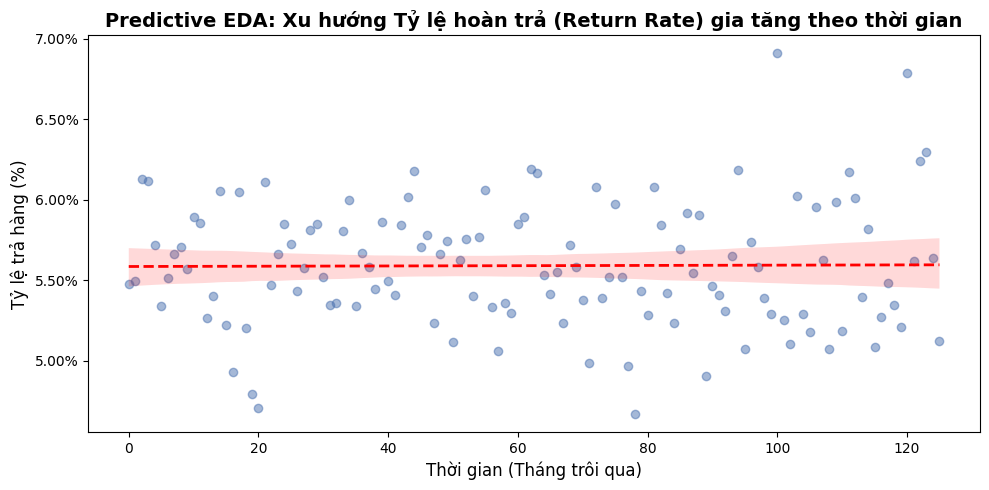

In [17]:
# --- BỔ SUNG: BIỂU ĐỒ PREDICTIVE (DỰ BÁO XU HƯỚNG TĂNG CỦA TỶ LỆ TRẢ HÀNG) ---
import matplotlib.ticker as mtick

# Tính tổng số đơn và số đơn bị trả theo từng tháng
monthly_returns = orders[orders['order_status'] == 'returned'].groupby('OrderMonth').size()
monthly_total = orders.groupby('OrderMonth').size()
trend_df = pd.DataFrame({'Returns': monthly_returns, 'Total': monthly_total}).dropna()
trend_df['Return_Rate'] = trend_df['Returns'] / trend_df['Total'] * 100
trend_df['Month_Index'] = np.arange(len(trend_df)) # Tạo trục thời gian dạng số

plt.figure(figsize=(10, 5))
# Dùng regplot để tự động vẽ đường xu hướng tuyến tính (Linear Regression)
sns.regplot(data=trend_df, x='Month_Index', y='Return_Rate', 
            scatter_kws={'alpha':0.5, 'color':'#4C72B0'}, 
            line_kws={'color':'red', 'linewidth':2, 'linestyle':'--'})

plt.title('Predictive EDA: Xu hướng Tỷ lệ hoàn trả (Return Rate) gia tăng theo thời gian', fontsize=14, fontweight='bold')
plt.xlabel('Thời gian (Tháng trôi qua)', fontsize=12)
plt.ylabel('Tỷ lệ trả hàng (%)', fontsize=12)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()